### Notebook 6: LFE Amplitudes via Cross-Correlation

So far we've just stacked the seismograms from individual LFEs and looked at the stacks.  However, we may also want to know something about the individual events: namely their amplitude or moment.

Here we'll combine data from across stations to estimate a relative amplitude for each LFE.  The analysis here gives no information about the absolute LFE moment, as we do not do any wave propagation modelling.  However, we can estimate how big each LFE is relative to the median.  

We take the approach used by Hawthorne et al (2019) to estimate amplitudes.  We estimate the relative amplitude of each LFE $j$ at each station $l$ by cross-correlating the individual signals with the stack.  Then we note that the observed amplitude of LFE $j$ at station $l$ is equal to 

$$\textrm{ amplitude of LFE } j \textrm{ at station } l  = \textrm{amplitude (sort of moment) of LFE }j \times \textrm{path effect amplitude of station }l$$

We obtain the left-hand-side values with cross-correlation.  Then we solve iteratively for a set of right-hand-side values that match the per-station per-LFE amplitudes.  We start by estimating the path effect amplitude at each station as the median of all the observations at that station.  Then we iteratively 
- remove these path effects and estimate the LFE amplitudes by taking the median across stations and
- remove the LFE amplitudes and estimate the path effects by taking the median across LFEs.

This approach is not very computationally intensive, and it tends to converge within a few tens of iterations.  

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import obspy
from obspy import UTCDateTime

import os,sys
import LFEAnalysis as lfeanalysis

from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg") #use png unless exporting, then switch to svg. 

### 1. Load and prepare the data

As usual, we first read in detections and the data.

In [2]:
# as before, we need to initialize an analysis object
data_directory = "/home/earthquakes1/homes/Julia/LFEAnalysis/DATA"
lf=lfeanalysis.lfeanalyse(fnum=1,region='Guerrero',catalog='Frank2014',data_directory=data_directory)

# and read the relevant detections
lf.read_detection_info()

In [3]:
# load the data
lf.read_data()

In [4]:
# normalise the seismograms
lf.normalize_data(single_norm=False)

# we may first need to discard any LFE intervals that contain NaNs, 
# as these will disrupt the filtering
lf.discard_data_with_nans()

# and bandpass filter
# we can filter the intervals with a 2-pass (non-causal) butterworth filter
# 1-2 Hz consistently used for Guerrero by frank, etc
lf.filter_data(flm=[1,2])

### 2. Stack

Then we make an initial stack and pick arrival times

In [5]:
# stack for each group
lf.stack_by_group() 

# and pick arrival times
lf.pick_stacks(minsnr=10)

# apply filtering to totstk
good_stations = set(lf.stns_stack)
lf.totstk = obspy.Stream([
    tr for tr in lf.totstk
    if tr.stats.station in good_stations
])

In [6]:
print(lf.stns_stack)
print(lf.stack_snrs)

print("totstk stations:", len(lf.totstk))

['AMAC' 'BUCU' 'CIEN' 'PALM' 'SATA' 'TEPO' 'TOMA']
{'ACAH': 3.9481780747631863, 'AMAC': 21.58110965721015, 'APOT': 1.3895466961356837, 'ATLA': 2.0106526519656036, 'BUCU': 111.05554303194246, 'CARR': 3.1759173920004127, 'CASA': 2.9794168973183472, 'CIEN': 171.67315015885134, 'CUCE': 3.6561245438838847, 'CUNO': 4.115280587968212, 'EL30': 1.6640591829329558, 'EL40': 9.047629686978608, 'ELPO': 4.452446754834168, 'HUIT': 2.1817106694163684, 'JIUT': 4.200697566631458, 'MAXE': 1.5276128619446996, 'MAZA': 4.924995818581308, 'OCOT': 1.2739388781704835, 'PABL': 1.4501387145001343, 'PALM': 100.00530587925587, 'PETA': 6.221540834978438, 'PLAT': 1.4487601067181812, 'PLAY': 1.856744617102101, 'PLLI': 3.5961411827791925, 'PUIX': 3.748025011432278, 'RIVI': 4.042235787022036, 'SAFE': 4.670515103039592, 'SAGR': 2.3460557590070215, 'SATA': 22.289801740957802, 'SJVH': 2.164620746363707, 'TEMI': 3.1071660442079536, 'TEPO': 13.649448749148387, 'TICO': 3.5728570477157455, 'TOMA': 28.56975988961856, 'TONA': 4

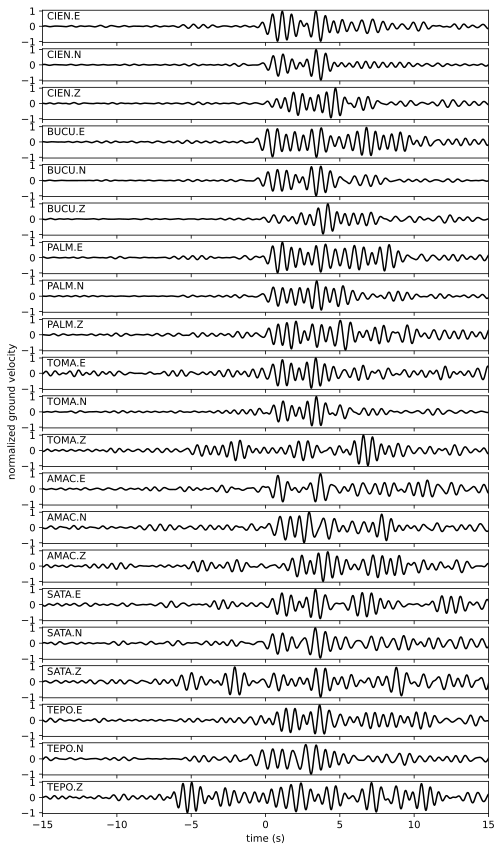

In [7]:
# have a look at what we get
stn = ["BUCU", "CIEN", "PALM", "CASA", "AMAC", "SATA", "TEPO", "XALI", "TOMA", "TONA", "SJVH", "SAFE"] #ten best stations for snr, as used by Frank
p=lf.plot_stacks(stype='all', Ns=12)

### 3. Compare the stack with individual records

Next, we cross-correlate the stack at each station with the seismograms from individual LFEs.  With the functin 'xc_with_stack', we can specify
- xcwin: the time window to consider, relative to the pick.
- max_shift : the maximum time shift to allow
- stns : the stations to consider: all of them by default

There are a few other parameters we could specify: a new stack to use or a modification of the stack to different durations, but we won't worry about those for now.

In [8]:
# all the cross-correlations
stns = ["BUCU", "CIEN", "PALM", "CASA", "AMAC", "SATA", "TEPO", "XALI"]
lf.xc_with_stack(max_shift=0.2)#stns=stns)

/home/earthquakes1/homes/Julia/LFEAnalysis/LFEAnalysis/_lfe_xc.py:155: RuntimeWarning: Mean of empty slice
  xcbystat=np.nanmean(self.xc,axis=3)
/home/earthquakes1/homes/Julia/LFEAnalysis/LFEAnalysis/_lfe_xc.py:156: RuntimeWarning: Mean of empty slice
  xcmean=np.nanmean(xcbystat,axis=2)


### 4. Examine the normalized cross-correlations

xc shape (41, 1159, 7, 3)


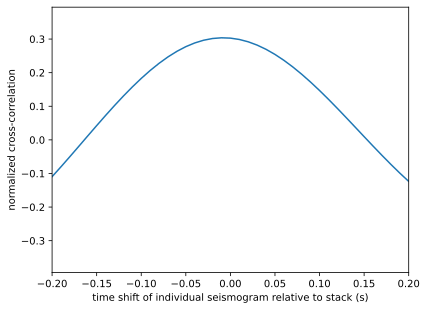

In [9]:
# we can examine several results of this cross-correlation
# the first is the set of normalized cross-correlation values, in lf.xc
# it has shape [# of time shifts, # of LFEs, # of stations considered, # number of components]
print('xc shape',lf.xc.shape)

# the time shifts used are listed in lf.xctim

# let's pick an LFE, station, and component to consider
kstat,kcmp=3,0
iok=np.where(~np.isnan(lf.xc[0,:,kstat,kcmp]))[0]
klfe=iok[15]

# we can plot the cross-correlation between the seismogram and the stack
# as a function of their time shift
plt.plot(lf.xctim,lf.xc[:,klfe,kstat,kcmp]);
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
plt.ylim(np.array([-1,1])*np.max(np.abs(lf.xc[:,klfe,kstat,kcmp]))*1.3);

/tmp/ipykernel_2937135/3315345238.py:6: RuntimeWarning: Mean of empty slice
  xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)


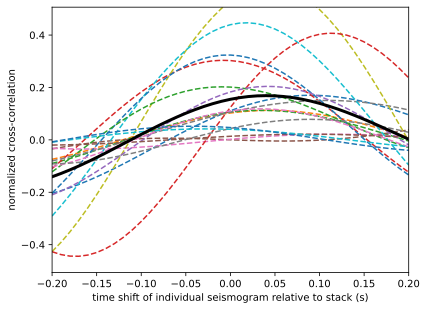

In [10]:
# or we could average the cross-correlations over stations and components 
# before plotting as a function of time shift

for kc in range(0,lf.xc_cmps.size):
    plt.plot(lf.xctim,lf.xc[:,klfe,:,kc],linestyle='--');
xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)
plt.plot(lf.xctim,xcm,color='k',linewidth=3);
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
plt.ylim(np.array([-1,1])*np.nanmax(np.abs(xcm).flatten())*3);

Note that the cross-correlations obtained from individual seismograms are often poor.  You get more significant results by averaging over stations, but this is tremor; cross-correlations lower than 0.2 are common.

### 5. Examine the stack-normalized cross-correlations

The cross-correlations obtained above and saved in lf.xc are fully normalized.  That means if we were comparing a portion of the individual seismogram $v_i(t)$ with a portion of the stack $v_s(t)$, using time lag $\Delta t$, we'd compute

$$x = \frac{\sum_k {v_i(t_k+\Delta t) v_s(t_k)} } {\sqrt{\sum_k v^2_i(t_k+\Delta t)\sum_k v^2_s(t_k)}}. $$

So multiplying at each time step $k$ and summing, and then normalizing by the power in the stack _and_ the power in the individual seismogram.

But if we wanted to know the value we'd have to multiply by to get from the stack to the seismogram, we could instead compute

$$A_i(\Delta t) = \frac{\sum_k {v_i(t_k+\Delta t) v_s(t_k)} } {\sum_k v^2_s(t_k)}, $$

where we just normalize by the stack's power.  These stack-normalized cross-correlations are saved in lf.xcamp.

The values $A$ are useful because they are the best estimate of the scaling between the stack and the seismogram.  Specifically, if we try to model the individual seismograms $v_i$ as scaled versions of the stack $v_s$, so that

$$v_i(t+\Delta t) = \textrm{ constant }\times v_s(t) + \textrm{ noise},$$

$A_i$ is the best estimate of the constant.

In [11]:
# xcamp contains the cross-correlations normalized by the power in the stack
# it has shape [# of time shifts, # of LFEs, # of stations considered, # number of channels]
print('Shape of fully normalized x-c, lf.xc',lf.xc.shape)
print('Shape of stack normalized x-c, lf.xcamp',lf.xcamp.shape)
print('Dimensions are [time shifts, LFE, station, channel]')

Shape of fully normalized x-c, lf.xc (41, 1159, 7, 3)
Shape of stack normalized x-c, lf.xcamp (41, 1159, 7, 3)
Dimensions are [time shifts, LFE, station, channel]


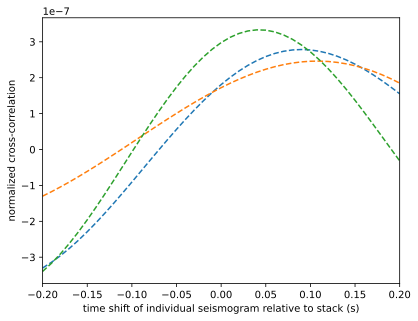

In [12]:
# we can plot the stack-normalized as a function of time shift for one LFE and station, with multiple channels
# the stack normalization values are useful because are the values needed to map the stack in lf.totstk,
# with its arbitrary normalization, to the (potentially time-shifted) seismograms
kstat=0
plt.plot(lf.xctim,lf.xcamp[:,klfe,kstat,:],linestyle='--');
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
#plt.ylim(np.array([-1,1])*np.nanmax(np.abs(xcm).flatten())*3);

### 6. Find the time shift that give the highest x-c

We can now find the time shift that gives the highest (fully normalized) cross-correlation.

Our approach here is to
- identify the best time shifts with the fully normalized cross-correlations and then
- extract the amplitudes with the stack-normalized cross-correlation at the appropriate time shift and
- redo the stacks with the time shift and amplitude information, if desired.

Note that different stations are different distances from the LFE, so they may have very different amplitudes.   Also, not all stations record all LFEs, so there's no guarantee that the amplitudes should be consistent across stations. _It thus makes sense to average the fully normalized cross-correlations over stations, but there's no reason to average the stack-normalized cross-correlations over stations.  However, we can average the stack-normalized x-c over channels, as all the channels at a given station are normalized by the same value before being averaged into the stack._

txcmax (1159,) [ 0.01  0.03 -0.02 ... -0.01 -0.01 -0.07]
xcmax (1159,) [0.08003941 0.06942109 0.08937939 ... 0.16553921 0.18193185 0.11294508]


/tmp/ipykernel_2937135/1256076461.py:9: RuntimeWarning: Mean of empty slice
  xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)


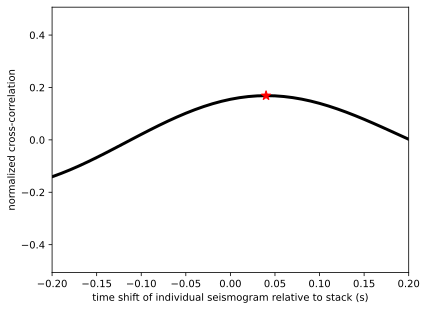

In [13]:
# the time shift that gives the highest fully normalized correlation for each LFE is saved in lf.txcmax
# this is after averaging over channels and stations
print('txcmax',lf.txcmax.shape,lf.txcmax)

# the values of those cross-correlations are in lf.xcmax
print('xcmax',lf.xcmax.shape,lf.xcmax)

# we can check this is correct for one LFE
xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)
plt.plot(lf.xctim,xcm,color='k',linewidth=3);
plt.plot(lf.txcmax[klfe],lf.xcmax[klfe],marker='*',color='red',markersize=10);
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
plt.ylim(np.array([-1,1])*np.nanmax(np.abs(xcm).flatten())*3);

### 7. Find the per-station LFE amplitude at the best time shift

We can grab out the best LFE amplitude for each LFE and station by grabbing the best-fitting value at each station.

In [14]:
# for instance, find the time index for the LFE we've been considering
ix=np.argmin(np.abs(lf.xctim-lf.txcmax[klfe]))

# and grab the amplitude at a given station and component
print('The amplitudes for LFE {:d} at station {:s} are, at the best time shift,'.format(klfe,lf.xc_stns[kstat]))
print('by channel: ',lf.xcamp[ix,klfe,kstat,:])
print('and averaged over channels: ',np.mean(lf.xcamp[ix,klfe,kstat,:]))

# the component averaged amplitudes are saved in lf.allamps
# which has dimensions [# of LFEs by # of stations]
print('\nThe function xc_with_stack has already computed this per-LFE and per-station average and saved it in lf.allamps: ')
print('allamps',lf.allamps.shape)

# check the average here
print('Saved average: ',lf.allamps[klfe,kstat])

The amplitudes for LFE 15 at station AMAC are, at the best time shift,
by channel:  [2.47812540e-07 2.15388493e-07 3.33260119e-07]
and averaged over channels:  2.6548705063581747e-07

The function xc_with_stack has already computed this per-LFE and per-station average and saved it in lf.allamps: 
allamps (1159, 7)
Saved average:  2.6548705063581747e-07


### 8. Estimate one amplitude per LFE

We now have one amplitude per LFE per station, for a total of $N_{stat} \times N_{lfe}$ values.  However, we'd like $N_{stat} + N_{lfe}$ values: a set of amplitudes for the LFEs along with a set of path effect amplitudes.  To obtain these amplitudes, we need to solve the equation below:

$$\textrm{ amplitude of LFE } j \textrm{ at station } l  = \textrm{amplitude (sort of moment) of LFE }j \times \textrm{path effect amplitude of station }l$$

To find a set of LFE amplitudes and path effect amplitudes that match the per-station amplitudes, we do an iterative calculation, using the function lf.separate_amplitudes.  We start by estimating the path effect amplitude at each station as the median of all the observations at that station.  Then we iteratively 
- remove these path effects and estimate the LFE amplitudes by taking the median across stations and
- remove the LFE amplitudes and estimate the path effects by taking the median across LFEs.


In [15]:
# this iteratively computes the median among stations and among LFEs to get 
# LFE and path effect amplitudes
lf.separate_amplitudes()

# the path effect amplitudes
print('\nPath effect amplitudes are saved in lf.statamp, with shape ',lf.statamp.shape)
print('lf.statamp: ',lf.statamp)

# the LFE amplitudes
print('\nLFE amplitudes are saved in lf.evamp, with shape ',lf.evamp.shape)
print('lf.evamp: ',lf.evamp)

Amplitudes met convergence criteria after 3 iterations

Path effect amplitudes are saved in lf.statamp, with shape  (7,)
lf.statamp:  [2.59526191e-07 2.50835673e-07 3.26881530e-07 2.73696580e-07
 3.56359546e-07 2.88946913e-07 7.71302495e-07]

LFE amplitudes are saved in lf.evamp, with shape  (1159,)
lf.evamp:  [0.24070354 0.15862472 0.68111565 ... 0.6242173  1.28811561 0.96377409]


/home/earthquakes1/homes/Julia/LFEAnalysis/LFEAnalysis/_lfe_xc.py:187: RuntimeWarning: All-NaN slice encountered
  evamp=np.nanmedian(np.divide(self.allamps,statamp),axis=1,


We can now plot bursts with amplitude grouping (large/small)

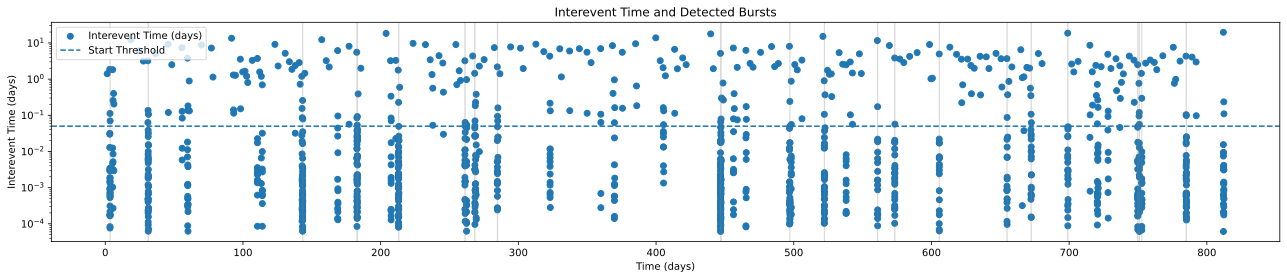

In [ ]:
lf.detect_lfe_bursts_interevent(start_threshold = 0.05, end_threshold = 0.1, dmin=15)
lf.split_events_by_detections()
lf.split_events_by_amplitude()

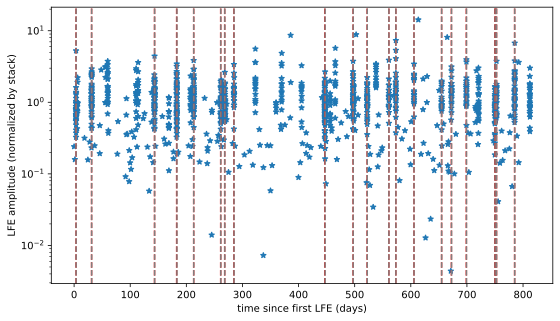

In [17]:
t0 = lf.tms[0]
x = np.array([(tm - t0) / 86400 for tm in lf.tms], dtype=float)
y = np.array(lf.evamp, dtype=float)

plt.figure(figsize=(9,5))
plt.plot(x, y, '*')
plt.yscale('log')
plt.ylabel('LFE amplitude (normalized by stack)')

start_times = np.zeros(len(lf.start_times))
end_times = np.zeros(len(lf.end_times))

#convert bursts from datetime to days since first LFE
for i in range(len(lf.start_times)):
    start_times[i] = (lf.start_times[i] - t0) / 86400
    end_times[i] = (lf.end_times[i] - t0) / 86400

# add lines for the detected bursts
for st, et in zip(start_times, end_times):
    plt.axvline(st, color='red', linestyle='--')
    plt.axvline(et, color='gray', linestyle='--')

plt.xlabel('time since first LFE (days)')
plt.show()


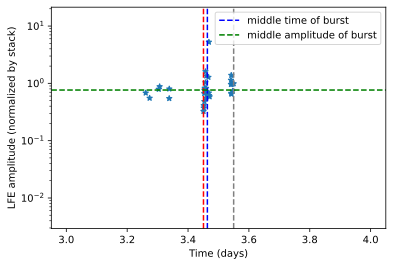

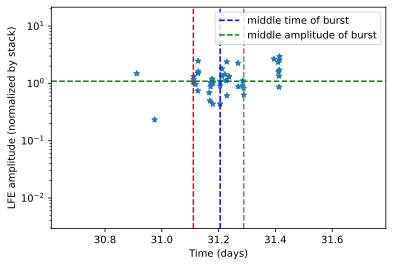

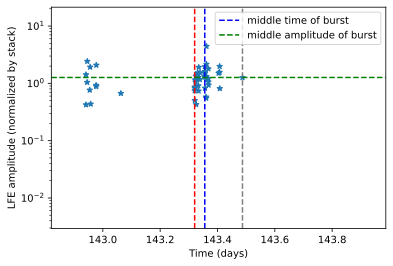

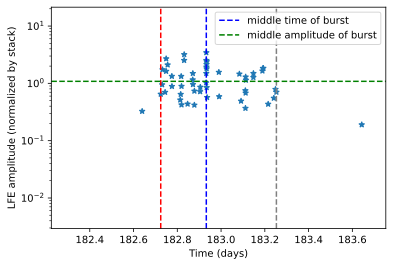

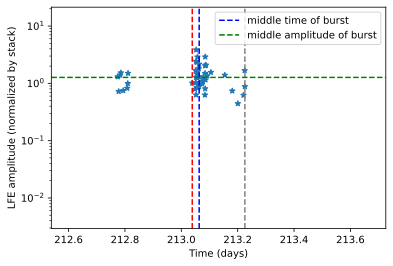

In [ ]:
# Plot some bursts as an example 

for i in range(5):
    t0 = lf.tms[0]

    x = np.array([(tm - t0) / 86400 for tm in lf.tms], dtype=float)
    y = np.array(lf.evamp, dtype=float)

    plt.figure(figsize=(6,4))
    plt.plot(x, y, '*')

    #convert middle time to days since first LFE
    middle_time = lf.middle_times[i]
    middle_time_days = (middle_time - t0) / 86400

    #Find median amplitude of the burst
    burst_indices = np.where((x >= start_times[i]) & (x <= end_times[i]))[0]
    middle_amplitude = np.median(y[burst_indices])

    # set limits 
    xmin, xmax = start_times[i]-0.5, end_times[i]+0.5
    plt.xlim(xmin, xmax)

    # add lines for the detected bursts
    plt.axvline(start_times[i], color='red', linestyle='--')
    plt.axvline(end_times[i], color='gray', linestyle='--')
    plt.axvline(middle_time_days, color='blue', linestyle='--', label='middle time of burst')
    plt.axhline(middle_amplitude, color='green', linestyle='--', label='middle amplitude of burst')

    plt.yscale('log')
    plt.ylabel('LFE amplitude (normalized by stack)')
    plt.xlabel('Time (days)')
    plt.legend()
    plt.show()

### 9. Recompute the stacks, weighting by LFE amplitude

It may now be interesting to redo the stacks, this time weighting the seismogram from each LFE by that LFE's amplitude, so that bigger LFEs contribute more.

In [19]:
# first save a copy of the previous stack
stack1=lf.totstk.copy()

# and restack
lf.stack_by_group(weighting='even_with_amp')
lf.pick_stacks(minsnr=10)

# apply filtering to totstk
good_stations = set(lf.stns_stack)
lf.totstk = obspy.Stream([
    tr for tr in lf.totstk
    if tr.stats.station in good_stations
])

['AMAC' 'BUCU' 'CIEN' 'PABL' 'PALM' 'TEPO' 'TOMA']
{'ACAH': 4.228196765074819, 'AMAC': 16.518037367957522, 'APOT': 1.2936549482162658, 'ATLA': 2.1788550438621965, 'BUCU': 120.48738495871416, 'CARR': 3.736631698309371, 'CASA': 2.5072830389059115, 'CIEN': 139.390731252432, 'CUCE': 3.9243749216275643, 'CUNO': 1.659645540653148, 'EL30': 2.297020815160461, 'EL40': 3.127728258761601, 'ELPO': 2.4046921283715594, 'HUIT': 4.82977910844026, 'JIUT': 3.2818040406261333, 'MAXE': 4.467209021139098, 'MAZA': 5.495064421191951, 'OCOT': 2.401567680033693, 'PABL': 20.876549685120608, 'PALM': 88.7847418800267, 'PETA': 5.645872034799598, 'PLAT': 2.481788382987345, 'PLAY': 0.9168337677248528, 'PLLI': 4.542853661550824, 'PUIX': 2.1363804873450727, 'RIVI': 3.7746194465003806, 'SAFE': 4.089400157231467, 'SAGR': 1.01773227190128, 'SATA': 5.642613937660775, 'SJVH': 4.529642810657708, 'TEMI': 2.2727739541240273, 'TEPO': 10.817233339085513, 'TICO': 1.5421111276753323, 'TOMA': 27.300462500420544, 'TONA': 3.28046302

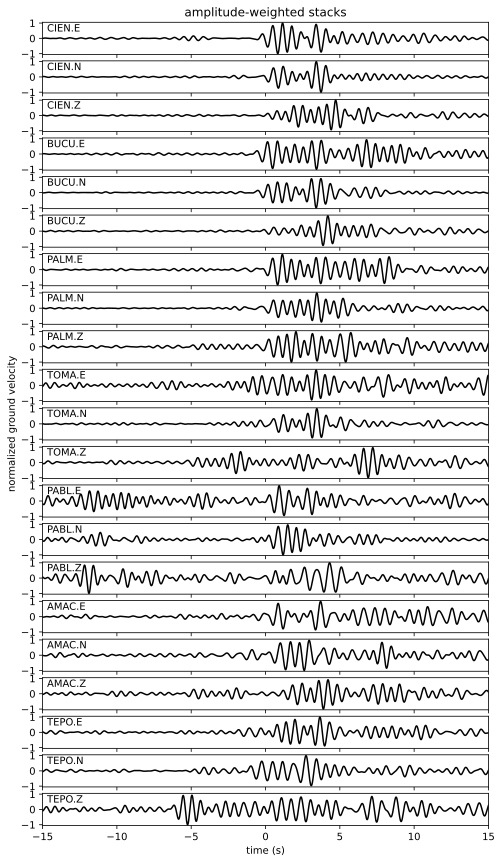

In [20]:
# have a look at what we get this time
p=lf.plot_stacks(stype='all', Ns = 43)#,stn=stn)
p[0].set_title('amplitude-weighted stacks');

print(lf.stns_stack)
print(lf.stack_snrs)

print("totstk stations:", len(lf.totstk))

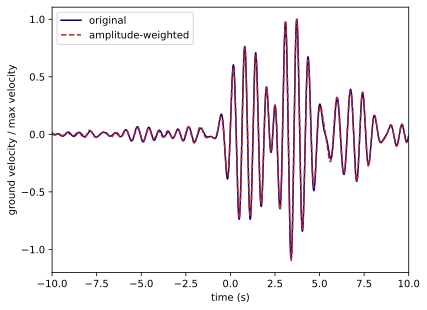

In [21]:
# and compare the original with the new amplitude-weighted stack
tr_orig=stack1.select(station='BUCU',channel='N')[0]
tr_new=lf.totstk.select(station='BUCU',channel='N')[0]

plt.plot(tr_orig.times()-tr_new.stats.t0,tr_orig.data/np.max(tr_orig.data),color='navy',
         label='original');
plt.plot(tr_new.times()-tr_new.stats.t0,tr_new.data/np.max(tr_new.data),color='firebrick',
         label='amplitude-weighted',linestyle='--');
plt.xlim([-10,10]);
plt.xlabel('time (s)');
plt.ylabel('ground velocity / max velocity');
plt.legend();

The results are often pretty similar, and comparing the amplitude seismogram during the LFE to a time interval beforehand suggests that the amplitude weighting only marginally changes the signal to noise ratio, not always for the better.  But there may be other weighting approaches that improve things: perhaps downweighting by the noise?

Note that for the moment, we've computed the best time shifts but haven't used these in the stacks.  That might also improve things.